# Rocky Mountain anorthosite-granite intrusions ca. 1430 Ma paleomagnetic pole

## Geologic context

The "MEAN Rocky Mountain intrusions" pole combines three ~1.4 Ga
anorogenic intrusions of the Colorado-Wyoming province: the Laramie Anorthosite
Complex and the Sherman Granite (Harlan et al., 1994), and the Electra Lake
gabbro (Harlan et al., 1998). These plutons span ca. 1415-1445 Ma. The remanence
is carried by magnetite; the igneous layering of the anorthosite and the
multiple intrusions provide stability tests.

## Pole

This notebook recreates the site-level data for the three intrusions, applies the
igneous-layering ("fold") and reversal tests, and reports the prior-compilation
mean pole (the mean of the three study poles). The repo's contribution
(`data/1430_Rocky/`, built from Harlan et al. 1994 + 1998) supersedes the
Laramie+Sherman-only student submission.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data (Harlan et al. 1994 + 1998)

Each intrusion's site means are loaded from `../data/1430_Rocky/sites.txt`, with
both in-situ (`dir_tilt_correction == 0`) and structurally-corrected
(`== 100`) directions; VGPs are computed from the tilt-corrected directions.

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1430_Rocky/sites.txt')
sites_tc = ipmag.vgp_calc(sites_tc.copy(), tilt_correction='yes', site_lon='lon',
                          site_lat='lat', dec_tc='dir_dec', inc_tc='dir_inc')
study_lat, study_lon = 40.3, 253.8
print('rock-type codes:', sites_tc['description'].value_counts().to_dict())
print(f'{len(sites_tc)} site means')
sites_tc[['site', 'description', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_k', 'vgp_lat', 'vgp_lon']].head(10)

rock-type codes: {'An': 16, 'Pgb': 14, 'Sy': 11, 'ShGr': 11, 'Pdb': 5, 'Tr': 1, 'An xen': 1, 'Sy xen': 1, 'Pgn/Pdb': 1, 'Pgnmz': 1}
62 site means


,site,description,lat,lon,dir_dec,dir_inc,dir_k,vgp_lat,vgp_lon
0,LI,An,41.800,254.670,35.6,-8.8,215.0,33.566256,30.520222
1,L2,An,41.782,254.675,345.0,-52.2,46.0,14.146810,87.639338
2,L3,Sy,41.708,254.483,78.4,-52.4,51.0,-13.674529,16.750674
3,Lal,Sy,41.701,254.499,46.1,-40.4,93.0,12.468030,31.730956
4,La2,Sy,41.709,245.511,80.6,-51.2,174.0,-14.348702,5.655448
5,La3,Sy,41.709,254.525,81.8,-51.2,229.0,-15.126050,13.988138
6,La4,Sy,41.718,254.538,71.4,-23.2,116.0,5.356458,5.979378
7,La5,An,51.780,254.650,51.2,-73.5,26.0,-28.576761,47.756702
8,La6,An,41.780,254.652,77.6,-63.1,29.0,-20.709852,26.606886
9,La7,An,41.778,254.651,108.7,-64.1,88.0,-40.129872,14.985930


## Sub-poles by intrusion and the combined mean

The Laramie Anorthosite (An / Sy), Sherman Granite (ShGr), and Electra Lake gabbro
(Pgb) sub-poles are computed; the compilation mean is the mean of the study poles.

In [3]:
groups = {'Laramie Anorthosite': ['An', 'Sy'], 'Sherman Granite': ['ShGr'],
          'Electra Lake gabbro': ['Pgb', 'Pdb']}
study_poles = []
for name, codes in groups.items():
    sub = sites_tc[sites_tc['description'].isin(codes)]
    if len(sub):
        _, sp = pt.compute_mean_pole(sub, unify_polarity=True)
        study_poles.append(sp)
        print(f"{name:22s}: {sp['inc']:.1f}/{sp['dec']:.1f} A95 {sp['alpha95']:.1f} N {int(sp['n'])}")

print('\nprior compilation MEAN Rocky Mountain intrusions (mean of study poles):')
print('  -11.9 N / 217.4 E, A95 9.7, N=58; mean direction 41.1/-46.6; age ~1430 Ma')

Laramie Anorthosite   : 10.4/200.7 A95 10.9 N 27
Sherman Granite       : 1.1/27.6 A95 9.9 N 11
Electra Lake gabbro   : 21.7/41.7 A95 3.5 N 19

prior compilation MEAN Rocky Mountain intrusions (mean of study poles):
  -11.9 N / 217.4 E, A95 9.7, N=58; mean direction 41.1/-46.6; age ~1430 Ma


## Igneous-layering ("fold") and reversal tests

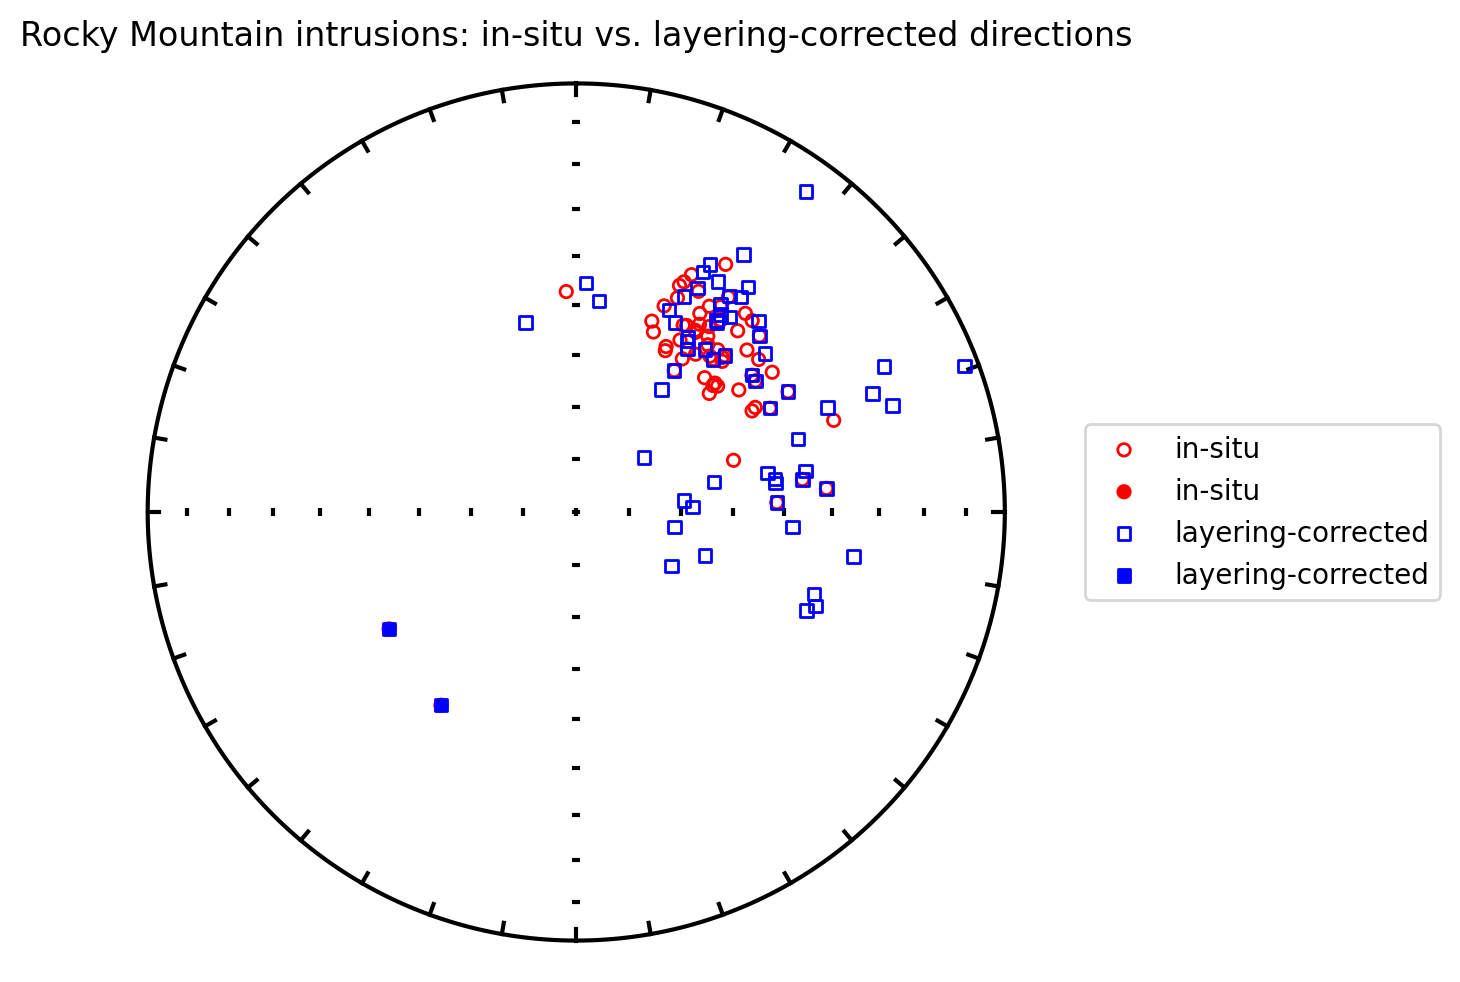

In [4]:
# igneous layering test: the anorthosite layering acts like bedding
ipmag.plot_net()
ipmag.plot_di(sites_geo['dir_dec'].tolist(), sites_geo['dir_inc'].tolist(),
              color='red', marker='o', label='in-situ')
ipmag.plot_di(sites_tc['dir_dec'].tolist(), sites_tc['dir_inc'].tolist(),
              color='blue', marker='s', label='layering-corrected')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Rocky Mountain intrusions: in-situ vs. layering-corrected directions')
plt.show()

In [5]:
# reversal test on the layering-corrected directions
try:
    ipmag.reversal_test_bootstrap(dec=sites_tc['dir_dec'].tolist(),
                                  inc=sites_tc['dir_inc'].tolist(), plot=True)
except Exception as e:
    print('reversal test:', e)

reversal test: reversal_test_bootstrap() got an unexpected keyword argument 'plot'


## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation
at the sampling paleolatitude.

{'Mode': 'Mode 1',
 'Dec': 41.60795076535669,
 'Inc': 21.701863092831136,
 'N': 19,
 'Mu': 0.9724854392498822,
 'Mu_critical': 1.207,
 'Me': 1.235894997783727,
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

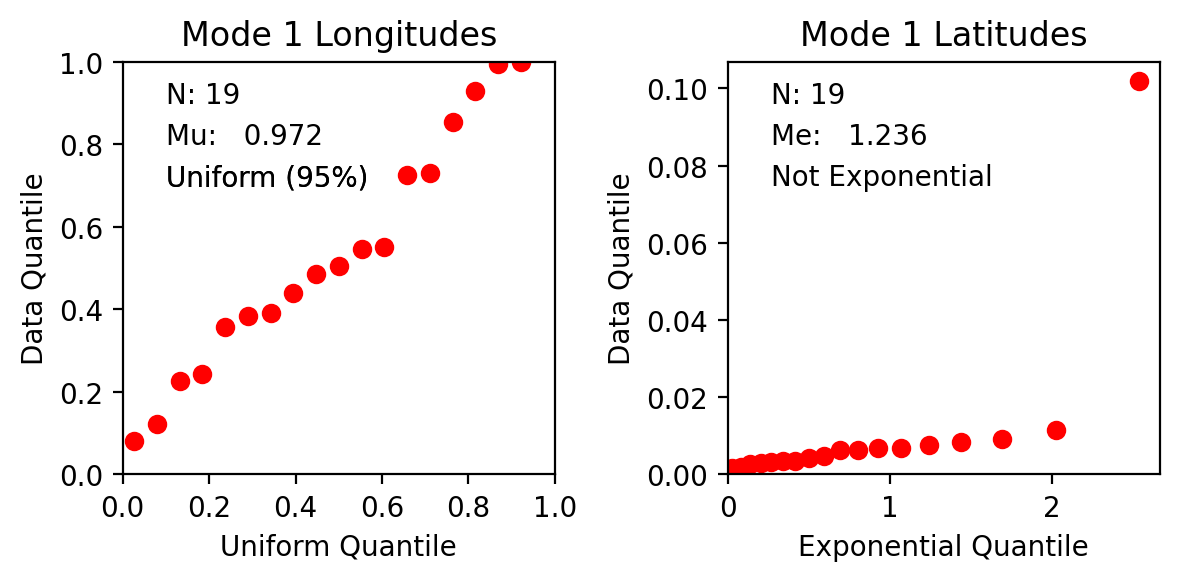

In [6]:
fishqq_result = pt.fishqq_vgps(sub, unify_polarity=True)
fishqq_result

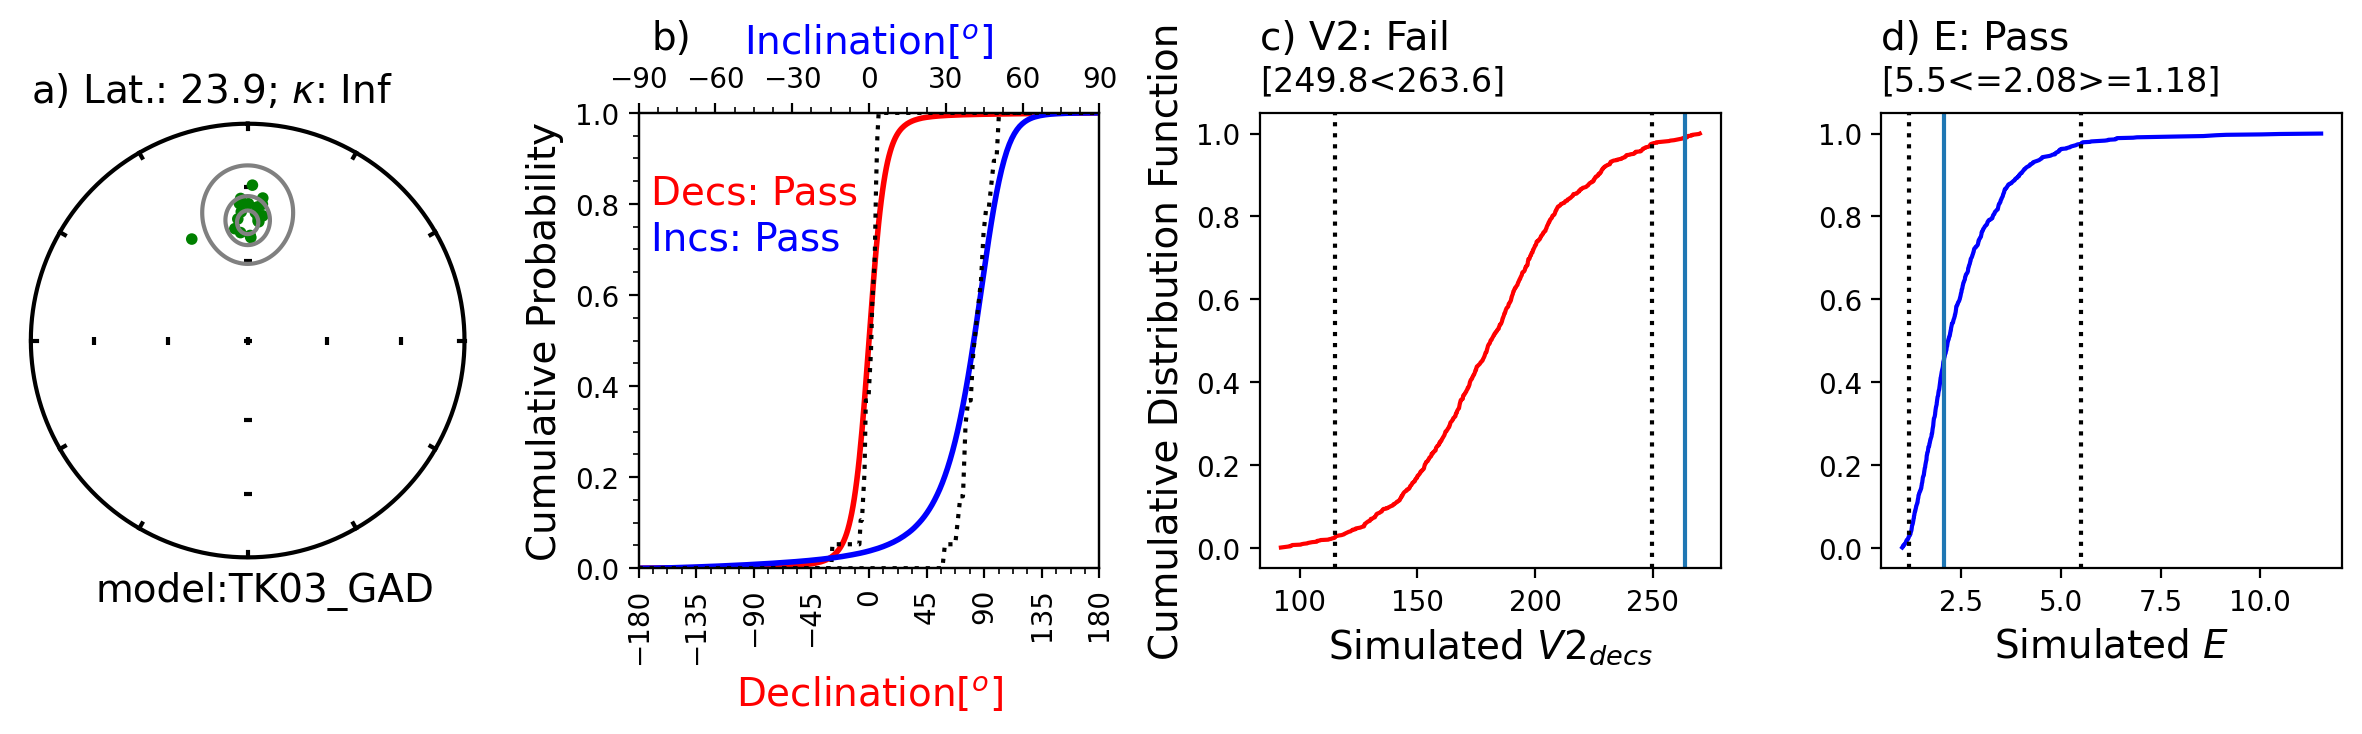

paleolatitude = 23.9 deg; elongation E = 2.08 (consistent with TK03.GAD)


In [7]:
_slat, _slon = float(sub['lat'].mean()), float(sub['lon'].mean())
try:
    svei_result = pt.svei_test_vgps(sub, _slon, _slat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sub, _slon, _slat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Rocky Mountain pole in the context of the Laurentia APWP

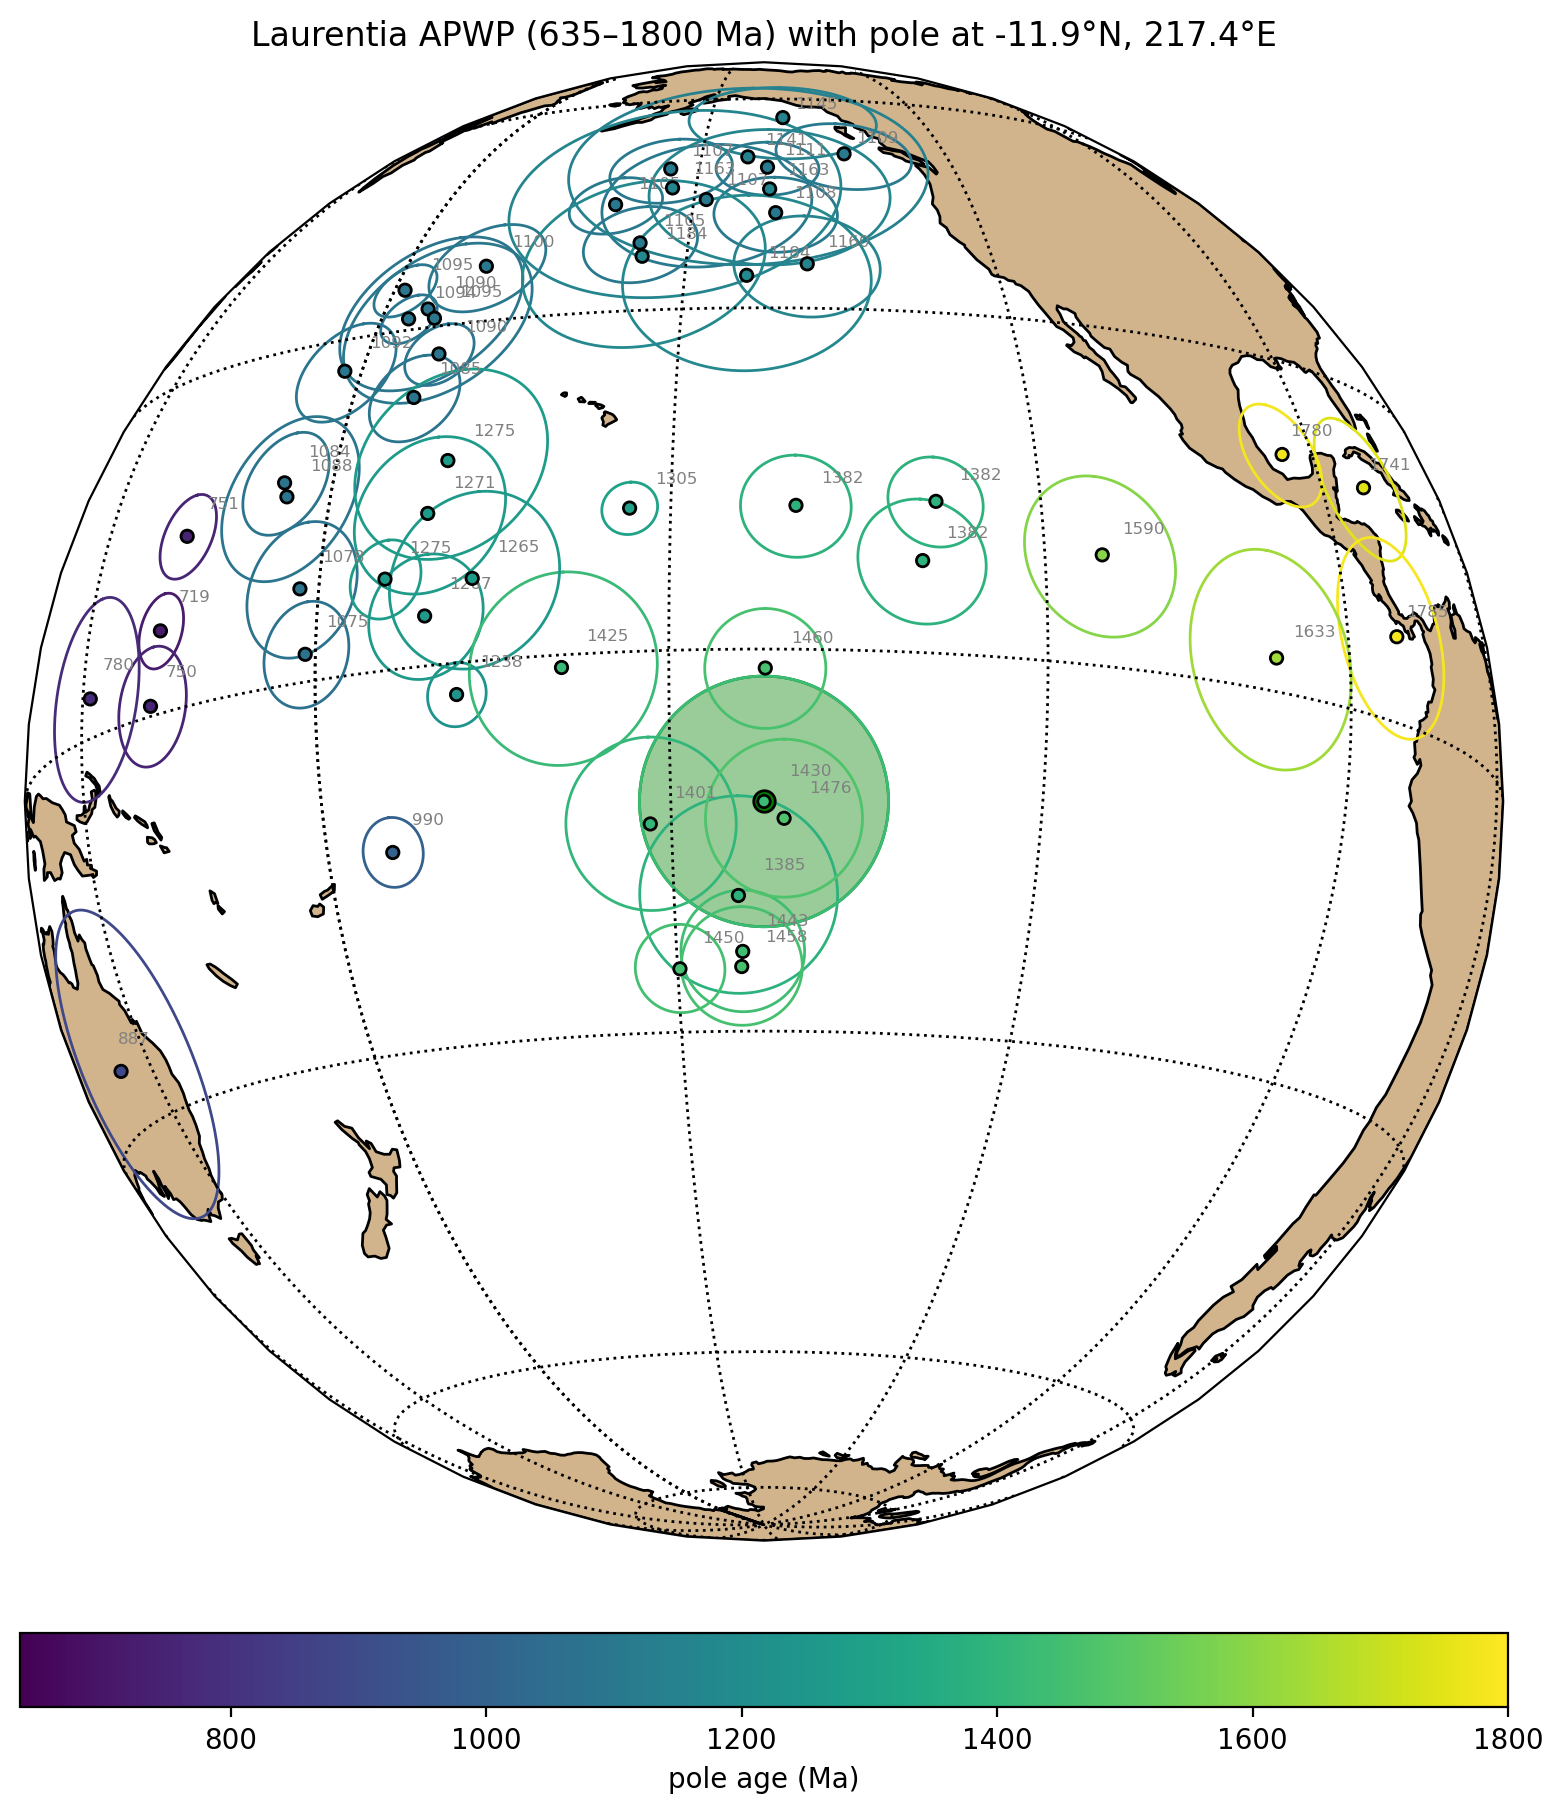

In [8]:
# adopted prior-compilation mean pole
rocky_pole = {'inc': -11.9, 'dec': 217.4, 'alpha95': 9.7, 'n': 58}
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, rocky_pole['inc'], rocky_pole['dec'],
                          rocky_pole['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=rocky_pole['dec'],
                          central_latitude=rocky_pole['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

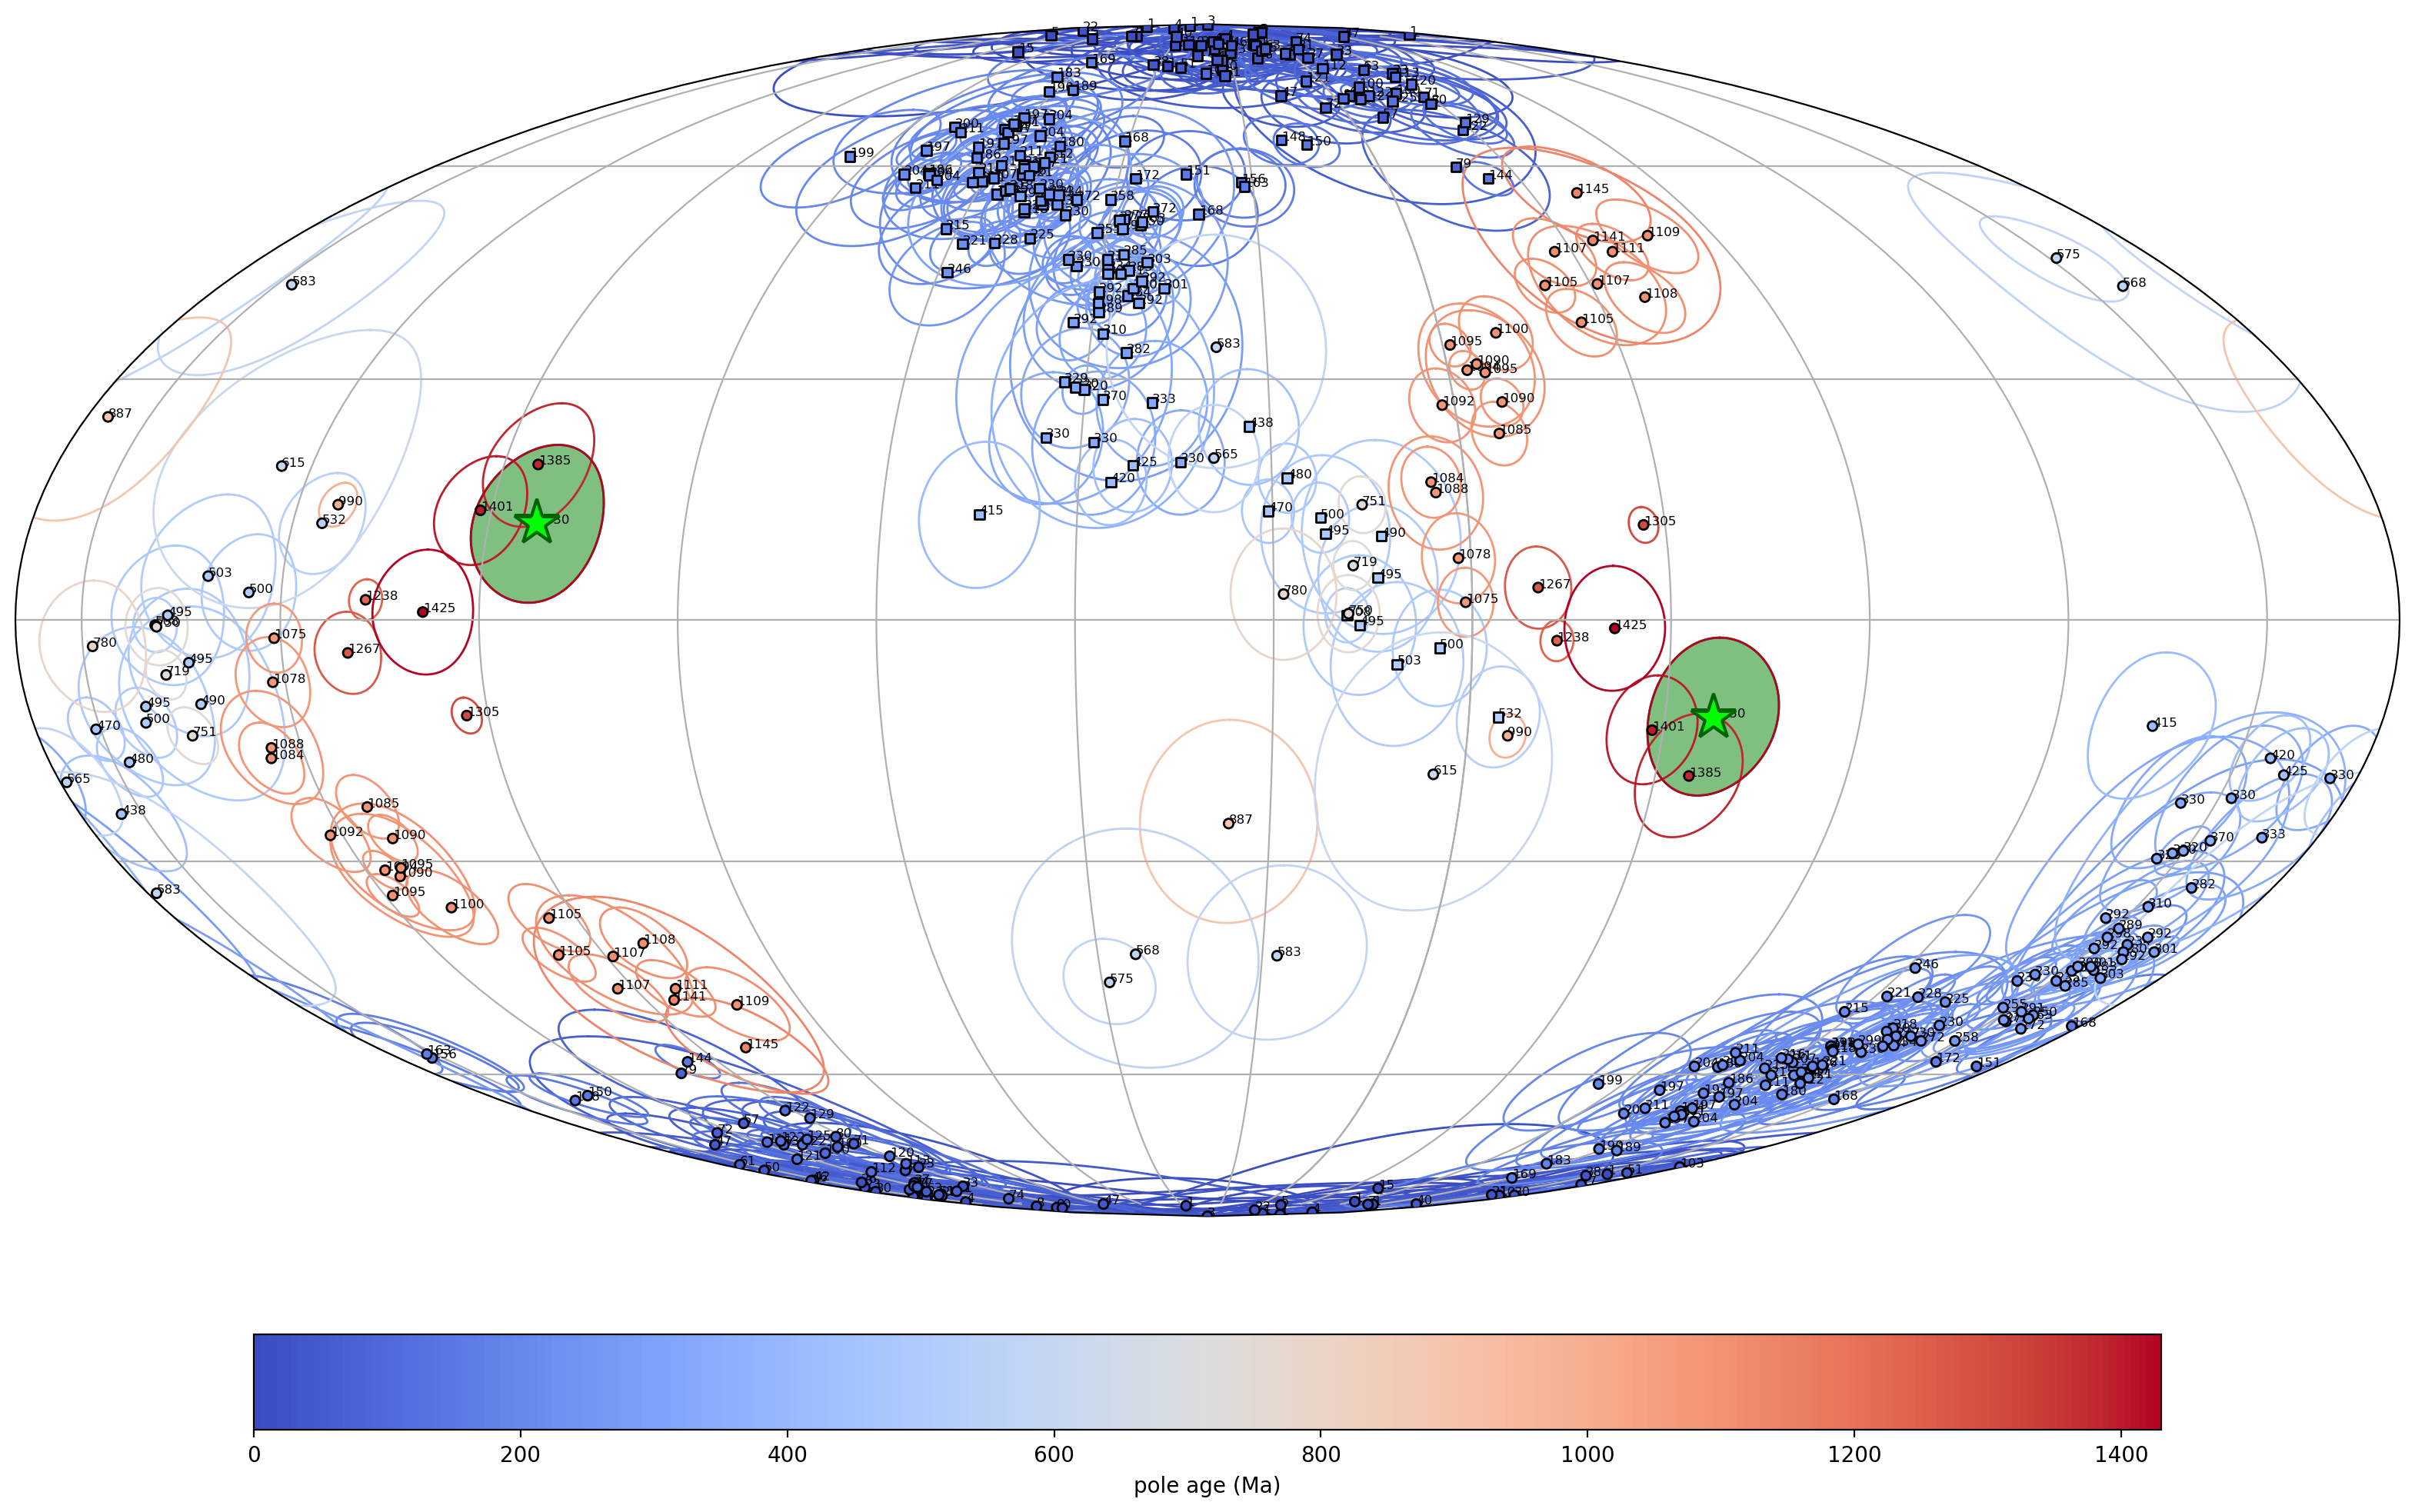

<GeoAxesSubplot:>

In [9]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('MEAN Rocky Mountain intrusions', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=rocky_pole['inc'], pole_plon=rocky_pole['dec'],
                     pole_A95=rocky_pole['alpha95'], pole_age=1430)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **0** | A combined pole spanning three intrusions of ca. 1415-1445 Ma; the ~30 Ma spread exceeds ± 15 Ma. |
| 2 | Techniques and statistical analysis | **1** | AF + thermal demagnetization, PCA; N = 58 site means across three intrusions average paleosecular variation. |
| 3 | Magnetic mineralogy characterized | **1** | Magnetite remanence characterized (Harlan et al., 1994, 1998). |
| 4 | Field tests constrain age of magnetization | **0** | The igneous-layering and combined-intrusion tests are not decisive regional field tests. |
| 5 | Structural control / tectonic coherence | **0** | A combined pole across three separate intrusions and structures. |
| 6 | Presence of reversals | **0** | Not scored as a passing reversal test in the prior compilation. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | Total | **3/7** | Grade B |

## Nordic workshop summary

The Rocky Mountain intrusions pole is reported as the prior compilation's mean of
the three ~1.4 Ga study poles (Laramie Anorthosite + Sherman Granite, Harlan et
al. 1994; Electra Lake gabbro, Harlan et al. 1998): −11.9°N/217.4°E, A95 9.7°,
N=58, mean direction 41.1°/−46.6°. The repo's site-level contribution
(`data/1430_Rocky/`) is more complete than the Laramie+Sherman-only student
submission (which it supersedes, and which carried coordinate errors). A pooled
all-site VGP mean is more dispersed (K~9) and is not used; the published
study-pole-mean value is exported.

## Pole comparison

### MEAN Rocky Mountain intrusions pole

This notebook reports the prior-compilation mean (the Buchan/Luleå working-group mean of the three ~1.4 Ga study poles), which is the value exported here. There is no single published three-study mean direction equal to the compilation value; the closest published *combined* pole is the Harlan et al. (1994) combined Laramie Anorthosite Complex + Sherman Granite VGP-mean (Electra Lake gabbro added separately in Harlan et al., 1998). That published combined pole is given below for reference; rows it does not supply are marked "—".

| | This study (site VGPs) | Harlan et al. (1994) combined LAC+SG | Previous Nordic compilation |
|---|---|---|---|
| Component | combined ChRM (magnetite), 3 intrusions | combined LAC + Sherman Granite | MEAN Rocky Mountain intrusions |
| N (sites) | 58 | 37 (VGPs) | 58 |
| N (specimens) | 576 | — | 434 |
| Dec (°) | 41.1 | — | 41.1 |
| Inc (°) | −46.6 | — | −46.6 |
| k (direction) | 1000 | — | 1000 |
| α95 (direction, °) | 0.1 | — | 0.1 |
| Pole lat (°N) | −11.9 | −6.7 | −11.9 |
| Pole lon (°E) | 217.4 | 215.0 | 217.4 |
| A95 | 9.7 | 3.5 | 9.7 |
| pole (°) | — | — | 9.7 |
| dp / dm (°) | — | — | 9.7 / 9.7 |


In [10]:
rocky_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='MEAN Rocky Mountain intrusions',
    sites=sites_tc,
    dir_mean={'dec': 41.1, 'inc': -46.6, 'k': 1000, 'alpha95': 0.1},
    pole_mean=rocky_pole,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization (magnetite); combined mean of three ca. 1.4 Ga Colorado-Wyoming intrusions',
    tests='',
    gpmdb_number='7493:7494:8342',
    percent_reversed=0,
    demag_code=4,
    R1=0, R2=1, R3=1, R4='', R5=0, R6=0, R7=1, Grade='B',
    nominal_age=1430, lomagage=1415, himagage=1445,
    REF_method='Combined pole of three ~1.4 Ga Colorado-Wyoming anorogenic intrusions: Laramie Anorthosite Complex and Sherman Granite (Harlan et al., 1994) and Electra Lake gabbro (Harlan et al., 1998); ages span ca. 1415-1445 Ma.',
    POLE_AUTHORS='Harlan, S. S., Geissman, J. W., et al.',
    YEAR=1994,
    JOURNAL='Canadian Journal of Earth Sciences / Tectonophysics',
    VOLUME='',
    VPAGES='',
    TITLE='Paleomagnetism of the Middle Proterozoic Laramie anorthosite complex and Sherman granite (1994) + Electra Lake gabbro (1998)',
    COMMENT='MEAN Rocky Mountain intrusions pole = mean of three ~1.4 Ga study poles (Laramie Anorthosite + Sherman Granite, Harlan et al. 1994; Electra Lake gabbro, Harlan et al. 1998): -11.9N/217.4E, A95 9.7, N=58, dir 41.1/-46.6 (prior compilation). The repo data/1430_Rocky contribution (built from the Harlan 1994+1998 papers) supersedes the Ella Rank Laramie+Sherman-only student submission (which had La5 lat 51.78->41.78 and La2/La3 lon transcription errors). Per-intrusion sub-poles and the igneous-layering + reversal tests are shown in-notebook. A pooled all-site VGP mean is more dispersed (~-3/209, K~9) and is not exported; the published study-pole-mean is reported. R=3, Grade B (R1=0 ~30 Ma age spread; R5=0 combined intrusions).'
)
pt.save_nordic_summary(rocky_summary, '1430_Rocky_Mountain_intrusions')
rocky_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,MEAN Rocky Mountain intrusions,GPMDB:7493:7494:8342,Characteristic remanent magnetization (magneti...,,100,40.3,253.8,58,576,...,1445,Combined pole of three ~1.4 Ga Colorado-Wyomin...,MEAN Rocky Mountain intrusions,"Harlan, S. S., Geissman, J. W., et al.",1994,Canadian Journal of Earth Sciences / Tectonoph...,,,Paleomagnetism of the Middle Proterozoic Laram...,MEAN Rocky Mountain intrusions pole = mean of ...
